# 09 - WEO Excel Visualization and EDA Lab

This lab uses the WEO Excel workbook to create graphs for different economic scenarios. The goal is not only to draw charts, but also to understand where the data enters each chart and how to read the output.

## Important: Use a Python Notebook Runtime

Run this notebook with a **Python 3** kernel in Jupyter, VS Code, JupyterLab, or Google Colab. Do not run these cells in SQL Server query mode.

This notebook uses the WEO Excel workbook from Module 4. Locally, it looks for `Module 4/labs/python-data-manipulation-database-connectivity/data/WEOApr2026all.xlsx`. In Google Colab, it also checks `/content/WEOApr2026all.xlsx` and can prompt you to upload the file if needed.

## 0. Install Packages

In [28]:
%pip install pandas numpy scipy matplotlib seaborn scikit-learn openpyxl joblib -q

Note: you may need to restart the kernel to use updated packages.


## 1. Imports

In [29]:
from pathlib import Path
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Display, Output, and Chart Style Settings

The pandas display settings only affect notebook table display. `sns.set_theme(style="whitegrid")` sets a clean Seaborn chart style with grid lines that make values easier to read.

In [30]:
# These settings only control how pandas tables are displayed in the notebook.
# They do not change the data.
pd.set_option("display.max_columns", 60)  # Show up to 60 columns before pandas hides columns with "...".
pd.set_option("display.width", 160)       # Make printed tables wider so rows wrap less often.

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid") if "sns" in globals() else None

## 3. Locate and Open the WEO Workbook

In [31]:
def find_weo_workbook():
    """Find the WEO workbook locally, in Colab, or through a Colab upload prompt."""
    candidate_paths = [
        Path("../../../Module 4/labs/python-data-manipulation-database-connectivity/data/WEOApr2026all.xlsx"),
        Path("Module 4/labs/python-data-manipulation-database-connectivity/data/WEOApr2026all.xlsx"),
        Path("data/WEOApr2026all.xlsx"),
        Path("/content/WEOApr2026all.xlsx"),
        Path("WEOApr2026all.xlsx"),
    ]

    for path in candidate_paths:
        if path.exists():
            return path

    # This block only runs in Google Colab. It lets a learner upload the Excel file manually.
    try:
        from google.colab import files
        print("Upload WEOApr2026all.xlsx from Module 4 to continue.")
        uploaded = files.upload()
        if "WEOApr2026all.xlsx" in uploaded:
            return Path("WEOApr2026all.xlsx")
    except Exception:
        pass

    raise FileNotFoundError(
        "WEOApr2026all.xlsx was not found. Run locally from the repo, or upload the Excel file in Google Colab."
    )

In [32]:
WEO_PATH = find_weo_workbook()
print("Using workbook:", WEO_PATH)

excel_file = pd.ExcelFile(WEO_PATH)
print("Workbook sheets:", excel_file.sheet_names)

Using workbook: ../../../Module 4/labs/python-data-manipulation-database-connectivity/data/WEOApr2026all.xlsx


Workbook sheets: ['April 2026 WEO', 'Countries', 'Country Groups', 'Commodity Prices', 'Country Group Composition']


## 4. Indicator Mapping and Helper Functions

We standardize column names and reshape the workbook before drawing charts. This keeps the plotting code easier to read.

In [33]:
# We use short, consistent snake_case names in our analysis DataFrames.
# The original WEO indicator IDs are kept only while extracting the data.
INDICATOR_LABELS = {
    "NGDP_RPCH": "gdp_growth_pct",
    "PCPIPCH": "inflation_pct",
    "LUR": "unemployment_rate",
    "BCA_NGDPD": "current_account_pct_gdp",
    "GGXWDG_NGDP": "government_debt_pct_gdp",
    "NGDPDPC": "gdp_per_capita_usd",
    "NID_NGDP": "investment_pct_gdp",
    "NGSD_NGDP": "savings_pct_gdp",
    "TX_RPCH": "export_volume_growth_pct",
    "TM_RPCH": "import_volume_growth_pct",
}

In [34]:
def standardize_column_names(frame):
    """Convert non-year column names to snake_case for consistent analysis code."""
    renamed_columns = {}

    for column in frame.columns:
        # WEO year columns arrive as integers such as 1980, 2026, and 2031.
        # Keep them as integers because they are easier to identify and melt later.
        if isinstance(column, int):
            renamed_columns[column] = column
            continue

        clean_name = (
            str(column)
            .strip()
            .lower()
            .replace(".", "_")
            .replace(" ", "_")
            .replace("-", "_")
        )
        renamed_columns[column] = clean_name

    return frame.rename(columns=renamed_columns)


def get_year_columns(frame):
    """Return columns that represent years, for example 1980, 2024, or 2031."""
    return [column for column in frame.columns if isinstance(column, int) or str(column).isdigit()]


def load_weo_sheets(path):
    """Load and standardize the useful WEO workbook sheets."""
    countries = standardize_column_names(pd.read_excel(path, sheet_name="Countries"))
    country_groups = standardize_column_names(pd.read_excel(path, sheet_name="Country Groups"))
    commodity_prices = standardize_column_names(pd.read_excel(path, sheet_name="Commodity Prices"))
    group_composition = standardize_column_names(pd.read_excel(path, sheet_name="Country Group Composition"))

    # This sheet uses compact column names like groupname and countrycode.
    # Rename them once so the rest of the notebook can use readable snake_case names.
    group_composition = group_composition.rename(columns={
        "groupcode": "group_code",
        "groupname": "group_name",
        "groupcode_previous": "group_code_previous",
        "countrycode": "country_id",
        "countryname": "country_name",
        "countrycode_previous": "country_code_previous",
    })

    return countries, country_groups, commodity_prices, group_composition


def make_long_indicator_data(frame, indicator_ids, source_sheet):
    """Convert WEO wide year columns into a tidy row-per-country-year format."""
    year_columns = get_year_columns(frame)
    id_columns = ["country_id", "country", "indicator_id", "indicator", "unit"]

    filtered = frame.loc[frame["indicator_id"].isin(indicator_ids), id_columns + year_columns].copy()

    long_df = filtered.melt(
        id_vars=id_columns,
        value_vars=year_columns,
        var_name="year",
        value_name="value",
    )
    long_df["year"] = long_df["year"].astype(int)
    long_df["value"] = pd.to_numeric(long_df["value"], errors="coerce")
    long_df["source_sheet"] = source_sheet
    return long_df


def make_country_macro_dataframe(countries, group_composition):
    """Create one country-year row with selected WEO indicators as columns."""
    country_long = make_long_indicator_data(countries, list(INDICATOR_LABELS), "Countries")

    country_macro = (
        country_long.pivot_table(
            index=["country_id", "country", "year"],
            columns="indicator_id",
            values="value",
            aggfunc="first",
        )
        .reset_index()
        .rename(columns=INDICATOR_LABELS)
    )

    # Remove the pivot column-axis name so displays do not show an old label above the header row.
    country_macro.columns.name = None

    advanced_codes = set(group_composition.loc[group_composition["group_name"].eq("Advanced Economies"), "country_id"])
    emerging_codes = set(group_composition.loc[group_composition["group_name"].eq("Emerging Market and Developing Economies"), "country_id"])
    ssa_codes = set(group_composition.loc[group_composition["group_name"].eq("Sub-Saharan Africa (SSA)"), "country_id"])

    country_macro["economic_group"] = np.select(
        [country_macro["country_id"].isin(advanced_codes), country_macro["country_id"].isin(emerging_codes)],
        ["Advanced Economies", "Emerging Market and Developing Economies"],
        default="Other",
    )
    country_macro["is_sub_saharan_africa"] = country_macro["country_id"].isin(ssa_codes)

    return country_macro, country_long


def make_group_long(country_groups):
    """Create long data for selected country-group indicators."""
    indicator_ids = ["NGDP_RPCH", "PCPIPCH", "TM_RPCH", "TX_RPCH"]
    return make_long_indicator_data(country_groups, indicator_ids, "Country Groups")


def make_commodity_long(commodity_prices):
    """Create long data for selected commodity price indicators."""
    indicator_ids = ["POILAPSP", "PFOODW", "PNGASW", "PCOALW", "PALLFNFW"]
    return make_long_indicator_data(commodity_prices, indicator_ids, "Commodity Prices")

## 5. Build the Visualization DataFrames

`country_macro` is used for country-level charts. `group_long` is used for World/regional trend charts. `commodity_long` is used for commodity price charts.

In [35]:
countries_raw, country_groups_raw, commodity_prices_raw, group_composition = load_weo_sheets(WEO_PATH)
country_macro, country_long = make_country_macro_dataframe(countries_raw, group_composition)
group_long = make_group_long(country_groups_raw)
commodity_long = make_commodity_long(commodity_prices_raw)

print("Country-year analytical rows:", len(country_macro))
print("Group trend rows:", len(group_long))
print("Commodity trend rows:", len(commodity_long))
display(country_macro.head())

Country-year analytical rows: 9398
Group trend rows: 2704
Commodity trend rows: 260


,country_id,country,year,current_account_pct_gdp,government_debt_pct_gdp,unemployment_rate,gdp_per_capita_usd,gdp_growth_pct,savings_pct_gdp,investment_pct_gdp,inflation_pct,import_volume_growth_pct,export_volume_growth_pct,economic_group,is_sub_saharan_africa
0,ABW,"Aruba, Kingdom of the Netherlands",1986,NaN,NaN,19.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Emerging Market and Developing Economies,False
1,ABW,"Aruba, Kingdom of the Netherlands",1987,NaN,NaN,14.5,NaN,16.079,NaN,NaN,3.639,NaN,NaN,Emerging Market and Developing Economies,False
2,ABW,"Aruba, Kingdom of the Netherlands",1988,NaN,NaN,5.0,NaN,18.640,NaN,NaN,3.121,NaN,NaN,Emerging Market and Developing Economies,False
3,ABW,"Aruba, Kingdom of the Netherlands",1989,NaN,NaN,1.5,NaN,12.095,NaN,NaN,3.989,NaN,NaN,Emerging Market and Developing Economies,False
4,ABW,"Aruba, Kingdom of the Netherlands",1990,NaN,NaN,1.3,NaN,3.977,NaN,NaN,5.838,NaN,NaN,Emerging Market and Developing Economies,False


## Chart Anatomy Reminder

Most Matplotlib and Seaborn charts follow the same logic:

- `data=...` is the DataFrame being plotted.
- `x=...` chooses the horizontal axis column.
- `y=...` chooses the vertical axis column.
- `hue=...` colors groups differently.
- `plt.title()`, `plt.xlabel()`, and `plt.ylabel()` make the chart readable.
- `plt.savefig()` writes the chart to the `outputs/` folder.

## 6. Scenario 1: GDP Growth Trend by Economic Group

A line chart is best when the x-axis is time. The dataset fed into this graph is `growth_trend`, filtered from the `Country Groups` sheet.

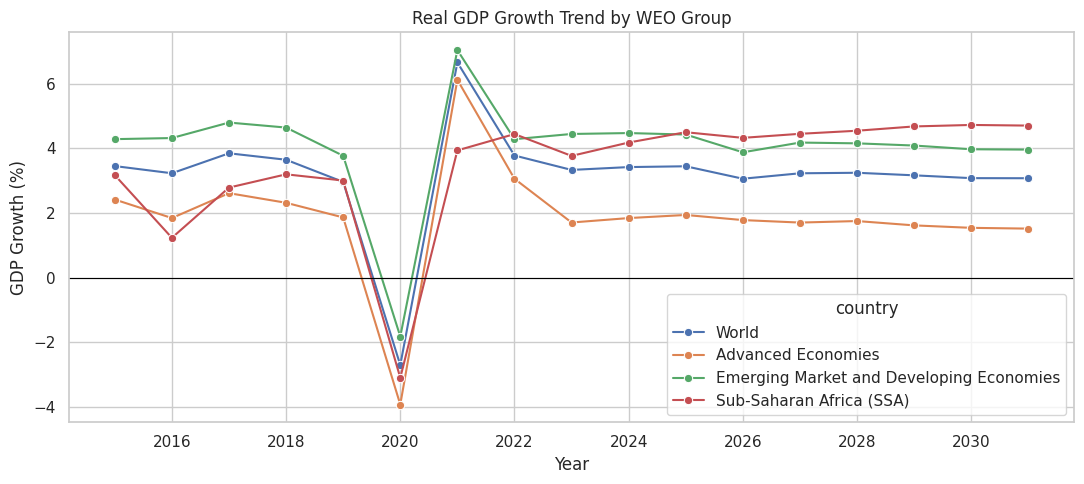

In [36]:
trend_groups = ["World", "Advanced Economies", "Emerging Market and Developing Economies", "Sub-Saharan Africa (SSA)"]

# Filter the long group DataFrame to one indicator and a readable year range.
growth_trend = group_long[
    group_long["country"].isin(trend_groups)
    & group_long["indicator_id"].eq("NGDP_RPCH")
    & group_long["year"].between(2015, 2031)
].copy()

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=growth_trend,  # DataFrame used to draw this chart.
    x="year",          # Horizontal axis: year.
    y="value",         # Vertical axis: GDP growth percentage.
    hue="country",     # Line color: economic group.
    marker="o",
)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Real GDP Growth Trend by WEO Group")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weo_group_gdp_growth_trend.png", dpi=150)
plt.show()

**How to read it:** compare the height and slope of each line. A value below zero means contraction. A sharp drop around 2020 reflects the global shock period in the historical data.

## 7. Scenario 2: Top and Bottom GDP Growth Countries

Horizontal bars are useful for ranked lists because country names remain readable.

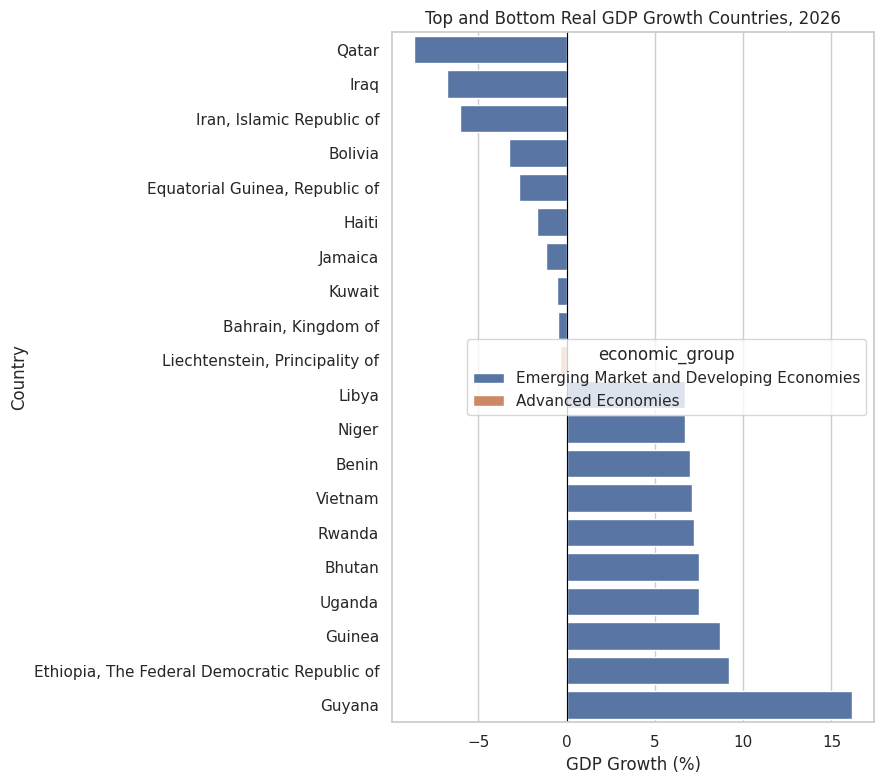

In [37]:
analysis_year = 2026
latest = country_macro[country_macro["year"].eq(analysis_year)].copy()

ranked_growth = latest.dropna(subset=["gdp_growth_pct"]).sort_values("gdp_growth_pct")
plot_ranked = pd.concat([ranked_growth.head(10), ranked_growth.tail(10)])

plt.figure(figsize=(9, 8))
sns.barplot(
    data=plot_ranked,       # DataFrame with only the lowest 10 and highest 10 countries.
    x="gdp_growth_pct",    # Bar length: GDP growth percentage.
    y="country",           # Bar label: country name.
    hue="economic_group",  # Color: country economic group.
    dodge=False,
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"Top and Bottom Real GDP Growth Countries, {analysis_year}")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weo_top_bottom_growth_bar.png", dpi=150)
plt.show()

**How to read it:** bars to the right of zero show growth; bars to the left show contraction. This chart is good for spotting countries that deserve follow-up analysis.

## 8. Scenario 3: Inflation vs GDP Growth Scatter Plot

Each dot is one country. Scatter plots are useful when checking whether two numeric variables appear related.

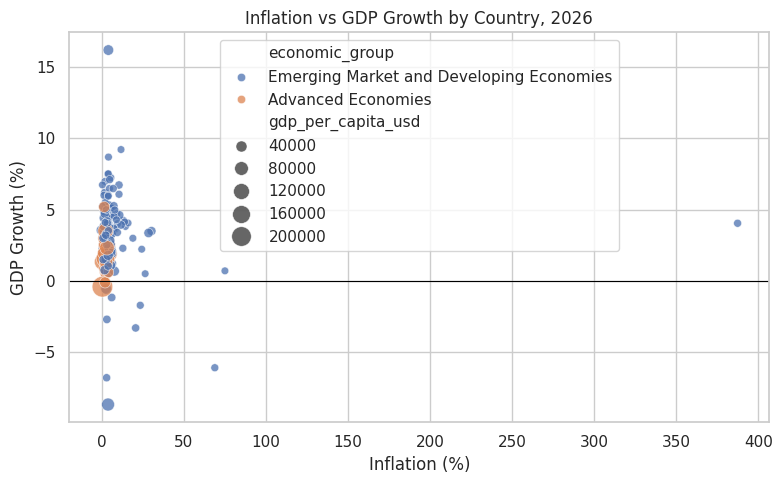

In [38]:
scatter_df = latest.dropna(subset=["inflation_pct", "gdp_growth_pct"]).copy()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=scatter_df,          # DataFrame passed to the scatter plot.
    x="inflation_pct",       # Horizontal location of each dot.
    y="gdp_growth_pct",      # Vertical location of each dot.
    hue="economic_group",    # Dot color by economic group.
    size="gdp_per_capita_usd",# Dot size by GDP per capita.
    sizes=(30, 220),
    alpha=0.75,
)
plt.axhline(0, color="black", linewidth=0.8)
plt.title(f"Inflation vs GDP Growth by Country, {analysis_year}")
plt.xlabel("Inflation (%)")
plt.ylabel("GDP Growth (%)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weo_inflation_vs_growth_scatter.png", dpi=150)
plt.show()

**How to read it:** look for a visible upward or downward cloud pattern. In the SciPy notebook, the simple correlation was weak for 2026, so do not overstate this chart as a strong relationship.

## 9. Scenario 4: Inflation Distribution

A histogram groups numeric values into bins and counts how many countries fall into each bin.

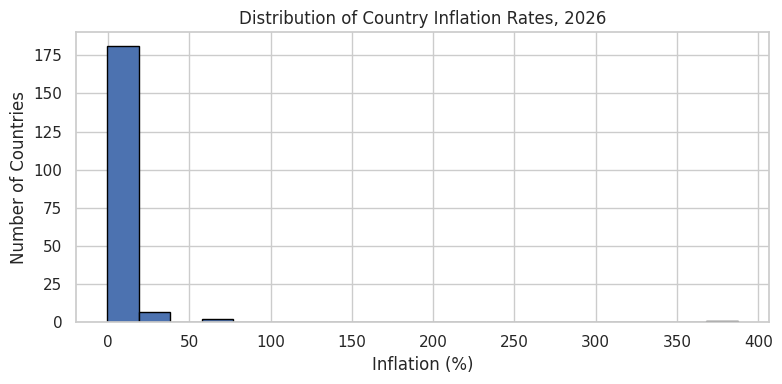

In [39]:
plt.figure(figsize=(8, 4))
plt.hist(
    latest["inflation_pct"].dropna(),  # One numeric column is enough for a histogram.
    bins=20,
    edgecolor="black",
)
plt.title(f"Distribution of Country Inflation Rates, {analysis_year}")
plt.xlabel("Inflation (%)")
plt.ylabel("Number of Countries")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weo_inflation_histogram.png", dpi=150)
plt.show()

**How to read it:** the tallest bars show the most common inflation ranges. Long tails indicate countries with unusually high or low inflation.

## 10. Scenario 5: Box Plot by Economic Group

A box plot compares medians, spread, and possible outliers across categories.

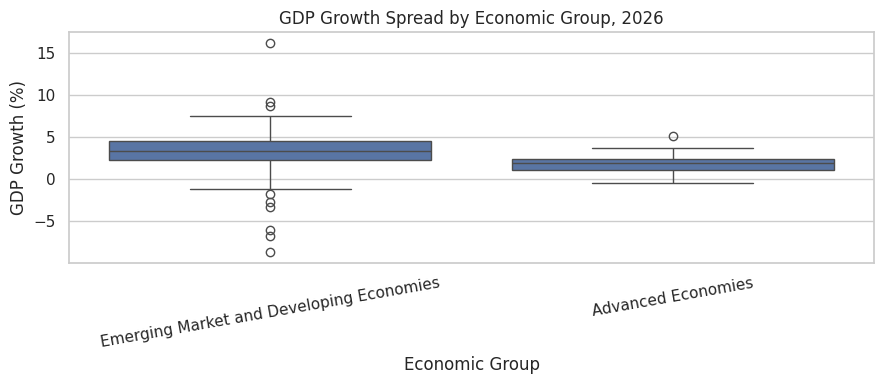

In [40]:
box_df = latest[latest["economic_group"].isin(["Advanced Economies", "Emerging Market and Developing Economies"])].copy()

plt.figure(figsize=(9, 4))
sns.boxplot(
    data=box_df,
    x="economic_group",  # Category on the x-axis.
    y="gdp_growth_pct",  # Numeric distribution shown by each box.
)
plt.title(f"GDP Growth Spread by Economic Group, {analysis_year}")
plt.xlabel("Economic Group")
plt.ylabel("GDP Growth (%)")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weo_growth_boxplot_by_group.png", dpi=150)
plt.show()

**How to read it:** the line inside each box is the median. A taller box means more spread. Dots beyond the whiskers are possible outliers.

## 11. Scenario 6: Correlation Heatmap

A heatmap uses color to show a matrix. Here it shows correlations among selected WEO indicators.

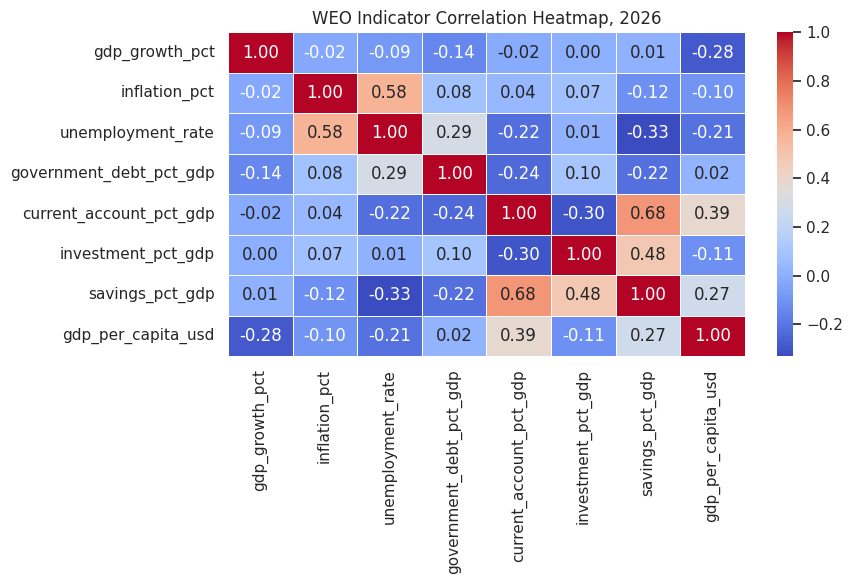

In [41]:
heatmap_columns = [
    "gdp_growth_pct",
    "inflation_pct",
    "unemployment_rate",
    "government_debt_pct_gdp",
    "current_account_pct_gdp",
    "investment_pct_gdp",
    "savings_pct_gdp",
    "gdp_per_capita_usd",
]

corr = latest[heatmap_columns].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    corr,        # Correlation matrix created from selected numeric columns.
    annot=True,  # Show the correlation number in each square.
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
)
plt.title(f"WEO Indicator Correlation Heatmap, {analysis_year}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weo_indicator_correlation_heatmap.png", dpi=150)
plt.show()

**How to read it:** values near `1` are strong positive relationships, values near `-1` are strong negative relationships, and values near `0` are weak linear relationships.

## 12. Scenario 7: Commodity Price Trends

Commodity indicators are in a separate workbook sheet. This chart compares selected commodity price series over time.

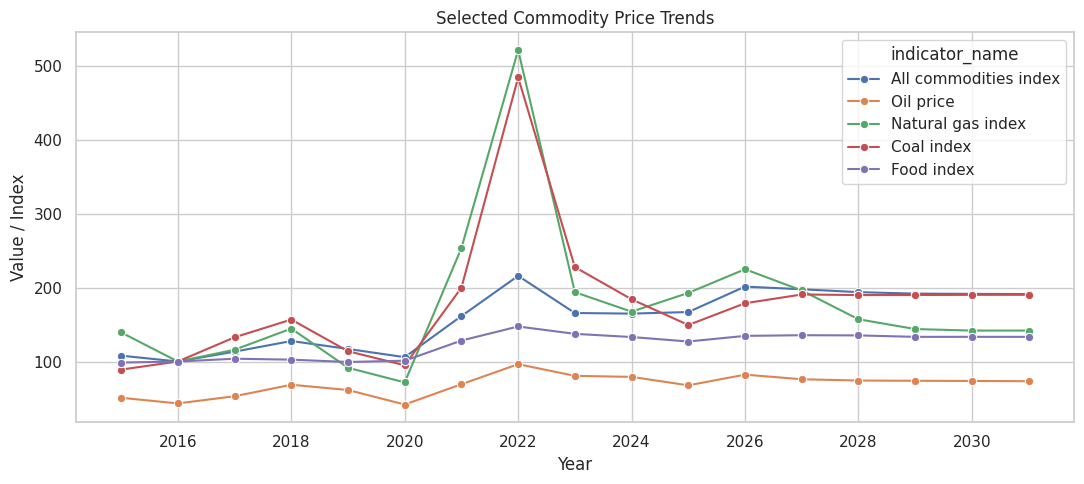

In [42]:
commodity_names = {
    "POILAPSP": "Oil price",
    "PFOODW": "Food index",
    "PNGASW": "Natural gas index",
    "PCOALW": "Coal index",
    "PALLFNFW": "All commodities index",
}

commodity_plot = commodity_long[commodity_long["year"].between(2015, 2031)].copy()
commodity_plot["indicator_name"] = commodity_plot["indicator_id"].map(commodity_names)

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=commodity_plot,
    x="year",
    y="value",
    hue="indicator_name",
    marker="o",
)
plt.title("Selected Commodity Price Trends")
plt.xlabel("Year")
plt.ylabel("Value / Index")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weo_commodity_price_trends.png", dpi=150)
plt.show()

**How to read it:** compare changes across commodity series. Remember that not every line has the same unit; some are indexes while oil is a price per barrel.

## 13. Scenario Dashboard

A dashboard combines several related charts for quick review. It is useful for reports, but each chart should still have a clear question.

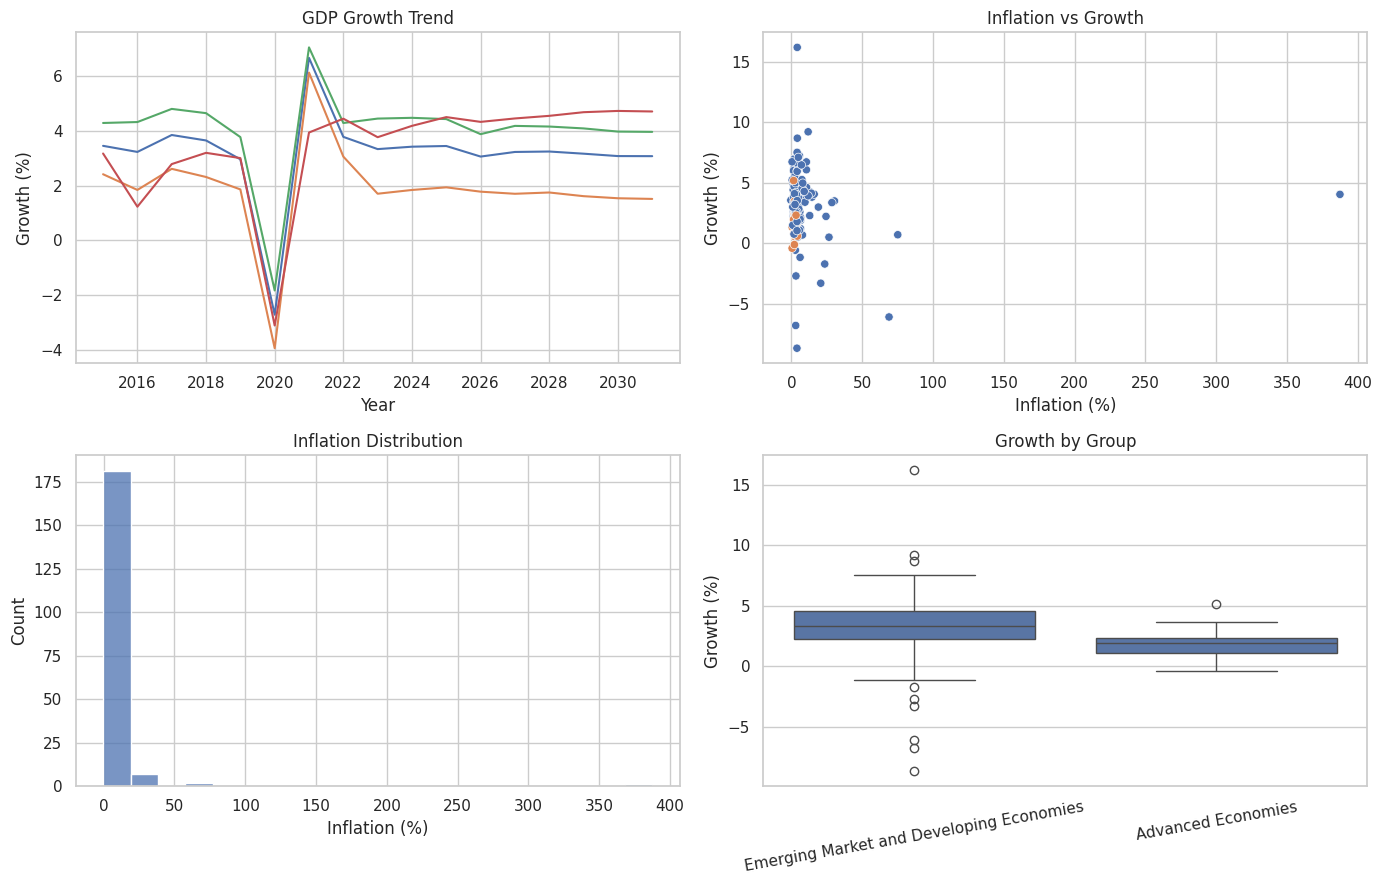

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.lineplot(data=growth_trend, x="year", y="value", hue="country", ax=axes[0, 0], legend=False)
axes[0, 0].set_title("GDP Growth Trend")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Growth (%)")

sns.scatterplot(data=scatter_df, x="inflation_pct", y="gdp_growth_pct", hue="economic_group", ax=axes[0, 1], legend=False)
axes[0, 1].set_title("Inflation vs Growth")
axes[0, 1].set_xlabel("Inflation (%)")
axes[0, 1].set_ylabel("Growth (%)")

sns.histplot(latest["inflation_pct"].dropna(), bins=20, ax=axes[1, 0])
axes[1, 0].set_title("Inflation Distribution")
axes[1, 0].set_xlabel("Inflation (%)")

sns.boxplot(data=box_df, x="economic_group", y="gdp_growth_pct", ax=axes[1, 1])
axes[1, 1].set_title("Growth by Group")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Growth (%)")
axes[1, 1].tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "weo_eda_dashboard.png", dpi=150)
plt.show()